# Neural Cellular Automata - Simple Texture

> This notebook requires a GPU. In Colab, choose Runtime -> Change runtime type -> Hardware accelerator -> GPU.

This trains a 64 x 64 2D NCA on `bubbly_0101.jpg`, decodes it with a SIREN scale factor of 8, and renders a 512 x 512 texture rollout video. It keeps the Colab run lightweight: no experiment directory, no checkpoint saving, and only the total loss is tracked.


### 1. Clone the repository

In [1]:
!git clone https://github.com/TheDevilWillBeBee/Cells2Pixels.git
%cd Cells2Pixels

/content/Cells2Pixels


### 2. Imports and device setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from PIL import Image

from losses.loss import Loss
from models.nca2d import NCA
from models.siren import Siren
from training.common import (
    make_grad_scaler,
    normalize_model_grads,
    optimizer_scheduler_step,
    set_seed,
)
from utils.misc import autocast_context
from utils.render import Renderer2D

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for this notebook. Enable a GPU runtime in Colab.')

device = torch.device('cuda:0')
print('Torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))


Torch: 2.11.0+cu128 | CUDA available: True
GPU: Tesla T4


### 3. Download the data

Target texture: data/textures_hr/bubbly_0101.jpg


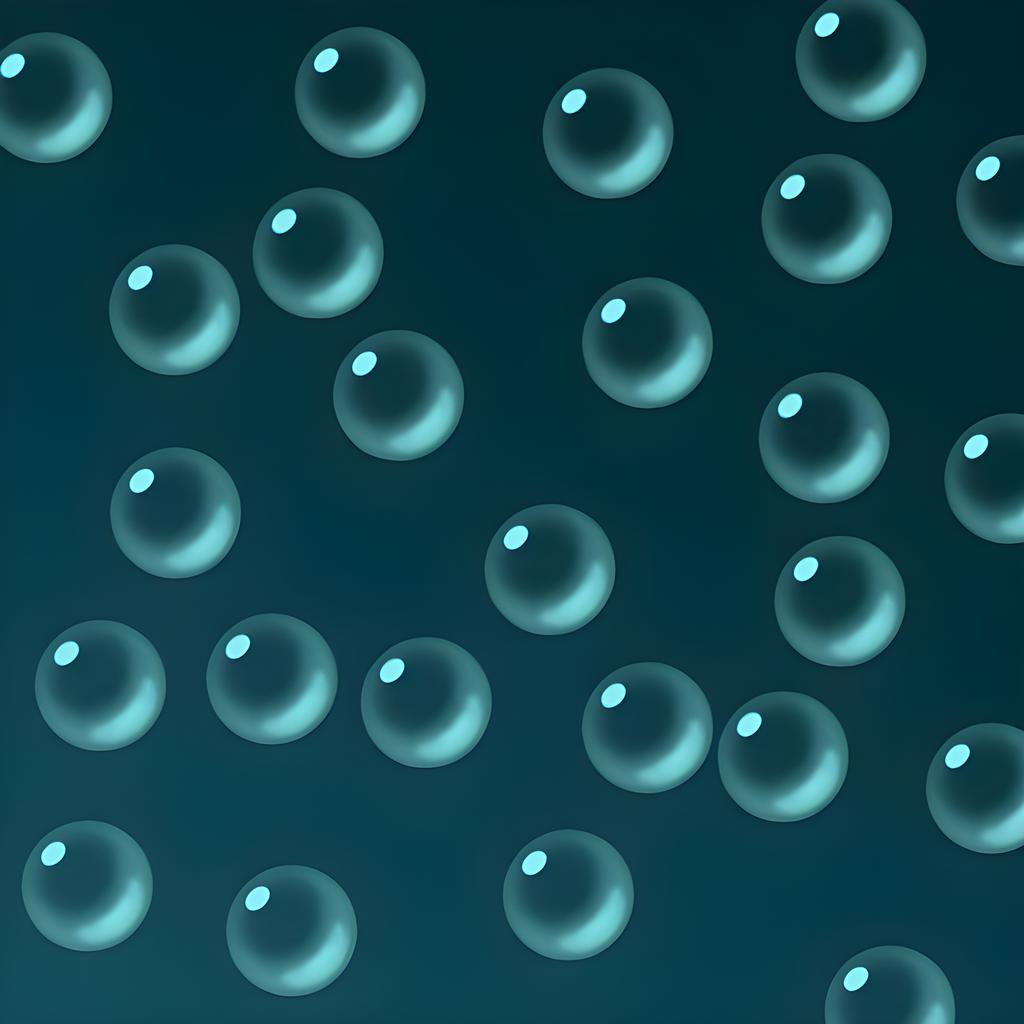

In [10]:
#@title {vertical-output: true}
!python scripts/download_data.py

TARGET_IMAGE_PATH = 'data/textures_hr/bubbly_0101.jpg'
print('Target texture:', TARGET_IMAGE_PATH)

target_image = Image.open(TARGET_IMAGE_PATH).convert('RGB')
display(target_image)


### 4. Training settings

In [4]:
SEED = 42
PRECISION = torch.float16
OUTPUT_TYPE = 's'

EPOCHS = 1500
BATCH_SIZE = 2
NCA_GRID_SIZE = (64, 64)
SIREN_SCALE_FACTOR = 8
POOL_SIZE = 256
INJECT_SEED_INTERVAL = 32
STEP_RANGE = (32, 96)
SUMMARY_INTERVAL = 25

TOTAL_CHANNELS = 3
OUTPUT_CHANNELS = {'rgb': [0, 1, 2]}

output_size = tuple(size * SIREN_SCALE_FACTOR for size in NCA_GRID_SIZE)
print('NCA grid:', NCA_GRID_SIZE)
print('SIREN scale factor:', SIREN_SCALE_FACTOR)
print('Output resolution:', f'{output_size[0]} x {output_size[1]}')


NCA grid: (64, 64)
SIREN scale factor: 8
Output resolution: 512 x 512


### 5. Initialize the model, renderer, loss, and pool

In [7]:
set_seed(SEED)
grid_size = NCA_GRID_SIZE

model = NCA(
    channels=16,
    fc_dim=128,
    device=device,
    precision=PRECISION,
).to(device)

nca_output_dim = model.channels
if OUTPUT_TYPE == 'z':
    nca_output_dim *= model.perception_kernels

siren = Siren(
    in_features=nca_output_dim,
    coord_dim=2,
    out_features=TOTAL_CHANNELS,
    hidden_features=32,
    hidden_layers=2,
    outermost_linear=True,
    fx='linear',
    activation='sin',
    num_frequencies=0,
    first_omega_0=10.0,
    hidden_omega_0=10.0,
).to(device)

loss_fn = Loss(
    overflow_loss_weight=100.0,
    appearance_loss_weight=2.0,
    motion_loss_weight=0.0,
    appearance_loss_kwargs=dict(
        target_image_size=[512, 512],
        patch_size=[128, 128],
        num_scales=3,
        relative_scale=1,
        max_image_size=[1024, 1024],
        target_images_path={'rgb': TARGET_IMAGE_PATH},
        total_channels=TOTAL_CHANNELS,
        output_channels=OUTPUT_CHANNELS,
        include_image_as_feature=False,
        num_pseudo_targets=0,
        vgg_layers=[1, 6, 11, 18, 25],
        ac_loss_weight=0.0,
        device=str(device),
    ),
)

renderer = Renderer2D(
    scale_factor=SIREN_SCALE_FACTOR,
    padding='circular',
    fs_shader='vanilla',
    precision=PRECISION,
)

with torch.no_grad():
    pool = model.seed(POOL_SIZE, grid_size[0], grid_size[1])

optimizer = torch.optim.Adam(list(model.parameters()) + list(siren.parameters()), lr=1e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[600, 1200],
    gamma=0.3,
)
scaler = make_grad_scaler(device, PRECISION)

n_params = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in siren.parameters())
print(f'Model + SIREN parameters: {n_params:,}')
print('Pool:', tuple(pool.shape), '| dtype:', pool.dtype)

Model + SIREN parameters: 13,187
Pool: (256, 16, 64, 64) | dtype: torch.float16


### 6. Training loop

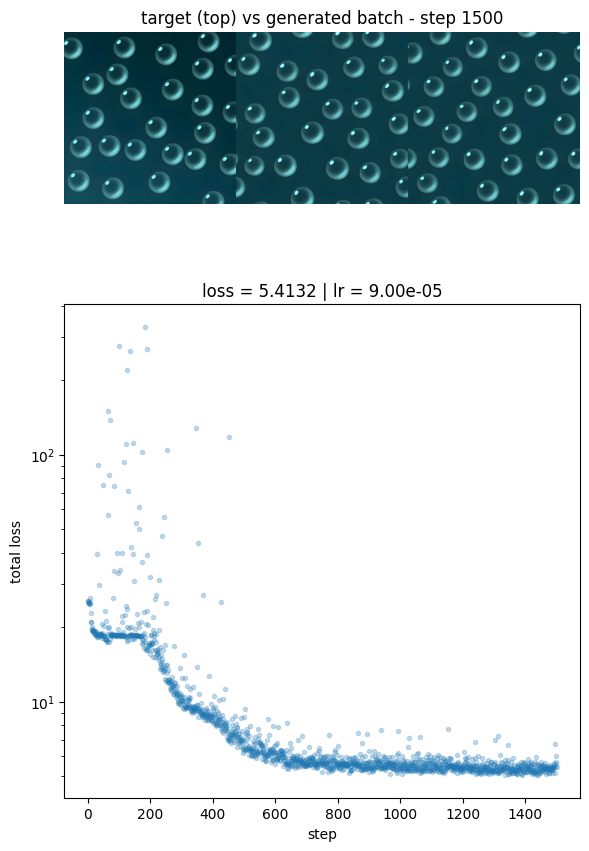

epoch 1500/1500 | total loss: 5.4132
Training complete.


In [8]:
#@title {vertical-output: true}
loss_history = []

model.train()
siren.train()

for epoch in range(EPOCHS + 1):
    with torch.no_grad():
        batch_idx = np.random.choice(len(pool), BATCH_SIZE, replace=False)
        x = pool[batch_idx]
        if epoch % INJECT_SEED_INTERVAL == 0:
            x[:1] = model.seed(1, grid_size[0], grid_size[1])

    step_n = np.random.randint(*STEP_RANGE)
    x0 = x
    z = None
    with autocast_context(device, PRECISION):
        for _ in range(step_n):
            x, z = model(x)

    x_render = x if OUTPUT_TYPE == 's' else z
    rendered = renderer.render(
        x_render.to(torch.float32).permute(0, 2, 3, 1),
        siren,
        None,
        fs_shader='vanilla',
    )
    rendered = rendered.permute(0, 3, 1, 2).to(torch.float32)

    input_dict = {
        'rendered_images': rendered,
        'nca_state': x,
        'image_before': x0[:, :3].to(torch.float32),
        'image_after': x[:, :3].to(torch.float32),
        'step_n': step_n,
    }
    return_summary = epoch % SUMMARY_INTERVAL == 0
    loss, summary = loss_fn(input_dict, return_log=False, return_summary=return_summary)

    if not torch.isfinite(loss):
        raise ValueError('Loss is NaN or Inf. Stopping training.')

    if PRECISION == torch.float16:
        scaler.scale(loss).backward()
    else:
        loss.backward()

    with torch.no_grad():
        normalize_model_grads(model)
        optimizer_scheduler_step(optimizer, scheduler, scaler, PRECISION)
        optimizer.zero_grad()
        pool[batch_idx] = x

    loss_value = loss.item()
    loss_history.append(loss_value)

    if return_summary:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 1, figsize=(6, 10))
        axes[0].imshow(summary['appearance-images'])
        axes[0].set_title(f'target (top) vs generated batch - step {epoch}')
        axes[0].axis('off')

        axes[1].plot(loss_history, '.', alpha=0.25)
        axes[1].set_yscale('log')
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('total loss')
        axes[1].set_title(f'loss = {loss_value:.4f} | lr = {scheduler.get_last_lr()[0]:.2e}')
        plt.tight_layout()
        plt.show()

        print(f'epoch {epoch}/{EPOCHS} | total loss: {loss_value:.6g}')

print('Training complete.')


### 7. Render a rollout video


In [9]:
#@title {vertical-output: true}
from IPython.display import Video
from tqdm.auto import trange

from utils.video import VideoWriter

VIDEO_PATH = 'bubbly_0101_texture.mp4'
VIDEO_FRAMES = 240
FPS = 30.0

model.eval()
siren.eval()

@torch.no_grad()
def render_frame(state, perception=None):
    x_render = state
    if OUTPUT_TYPE == 'z' and perception is not None:
        x_render = perception
    image = renderer.render(
        x_render.to(torch.float32).permute(0, 2, 3, 1),
        siren,
        target_channels=OUTPUT_CHANNELS,
        fs_shader='vanilla',
        hard_clamp=True,
    )
    return np.asarray(Renderer2D.to_pil(image, target_channels=OUTPUT_CHANNELS))

with VideoWriter(VIDEO_PATH, fps=FPS) as video:
    x = model.seed(1, grid_size[0], grid_size[1])
    z = None
    for frame_idx in trange(VIDEO_FRAMES, desc='Rendering video'):
        video.add(render_frame(x, z))
        step_n = 1 if frame_idx < 60 else 2 if frame_idx < 120 else 4 if frame_idx < 180 else 8
        with autocast_context(device, PRECISION):
            for _ in range(step_n):
                x, z = model(x)

Video(VIDEO_PATH, embed=True, width=512)

Rendering video:   0%|          | 0/240 [00:00<?, ?it/s]